### TNCDR-mitigating Qiskit results

Retrieve results on IBM machine, compute exact expectation values using hybrid stabilizers-MPO and execute data-driven error mitigation with these data.

In [1]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Qibo related stuff
from qibo import set_backend
from qibo import symbols, hamiltonians

# Qiskit related stuff
from qiskit_ibm_runtime import RuntimeDecoder
from tncdr.targets.ansatze import FloquetAnsatz, TranspiledAnsatz
from tncdr.evolutors.models import HybridSurrogate

In [13]:
# Set Qibo backend, for a double check
set_backend("numpy")

path = "30q_5l"

[Qibo 0.2.20|INFO|2025-07-03 18:50:58]: Using numpy backend on /CPU:0


In [14]:
# Loading results from hardware run
with open(f"{path}/results/tncdr_results.json", "r") as file:
    result = json.load(file, cls=RuntimeDecoder)

values = []
for res in result:
    values.append(res.data.evs)

In [15]:
result.metadata

{'dynamical_decoupling': {'enable': False,
  'sequence_type': 'XX',
  'extra_slack_distribution': 'middle',
  'scheduling_method': 'alap'},
 'twirling': {'enable_gates': False,
  'enable_measure': True,
  'num_randomizations': 'auto',
  'shots_per_randomization': 'auto',
  'interleave_randomizations': True,
  'strategy': 'active-accum'},
 'resilience': {'measure_mitigation': True,
  'zne_mitigation': False,
  'pec_mitigation': False},
 'version': 2}

In [16]:
result[0].data.evs

array(-0.00150432)

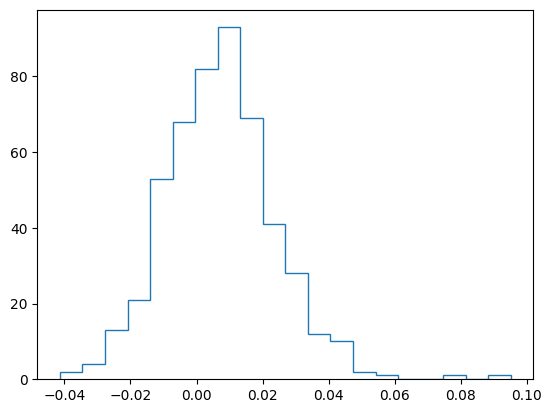

In [17]:
plt.hist(values, histtype="step", lw=4, bins=20)
plt.show()

In [7]:
# Loading the configuration to reconstruct the ansatz
with open(f"{path}/config.json") as f:
    config = json.load(f)

print(config)

{'nqubits': 50, 'nlayers': 2, 'b': 1.2566370614359172, 'theta': 1.5707963267948966, 'replacement_probability': 0.7, 'ncircuits': 500, 'random_seed': 42, 'local_pauli_noise_sigma': 0.003, 'max_bond_dimension': 128, 'nruns': 10, 'plot': True, 'save_results': True}


In [8]:
# Load all the executed circuits' parameters
circuit_params = []
for i in range(500):
    circuit_params.append(np.load(f"{path}/circuits/params_circuit{i}.npy"))

In [9]:
# Construct Floquet inspired ansatz and related transpiled one
floq_ansatz = FloquetAnsatz(
    nqubits=14,
    # nqubits=config["nqubits"],
    nlayers=config["nlayers"],
    b=config["b"],
    theta=config["theta"],
)

print(len(floq_ansatz.circuit.get_parameters()))
# Because it works with transpiled for now
#transpiled_ansatz = TranspiledAnsatz(original_circuit=floq_ansatz.circuit)
#print(len(transpiled_ansatz.circuit.get_parameters()))

261


In [10]:
# Construct observable
# Target qubit
q = int(config["nqubits"]/2)
obs = "I" * (q) + "X" + "I" * (config["nqubits"] - (q + 1))
print(obs)

IIIIIIIIIIIIIIIIIIIIIIIIIXIIIIIIIIIIIIIIIIIIIIIIII


In [11]:
# Construct hybrid surrogate and test it
it = time.time()
hs = HybridSurrogate(ansatz=floq_ansatz, max_bond_dimension=128)

# repl_prob = 0. means we leave it as it is
%prun -s cumulative expval, _  = hs.expectation_from_partition(observable=obs,replacement_probability=0.,)

print(expval, time.time() - it)

Check stab layers


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 208/208 [12:13<00:00,  3.53s/it]


Final stab layer
Contraction starts


13it [00:00, 477.75it/s]

 0.9999999999999978 733.7502658367157


         9739554 function calls (9736081 primitive calls) in 732.195 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     12/1    0.000    0.000  732.195  732.195 {built-in method builtins.exec}
        1    0.000    0.000  732.195  732.195 <string>:1(<module>)
        1    0.002    0.002  732.195  732.195 models.py:75(expectation_from_partition)
      208    0.002    0.000  729.329    3.506 circuit_mps.py:167(pauli_rot)
      208    0.128    0.001  729.000    3.505 circuit_mps.py:261(apply)
     2704    0.139    0.000  664.609    0.246 tensor_network.py:171(svd_decomposition)
     2704  661.713    0.245  661.859    0.245 _decomp_svd.py:13(svd)
    11299    0.105    0.000   39.039    0.003 tensor_network.py:124(contract)
    11286    0.218    0.000   36.600    0.003 tensor_network.py:343(_contract_separate_nodes)
    11286   32.591    0.003   32.866    0.003 numeric.py:990(tensordot)
     2496   24.595    0.010   24.686  

In [ ]:
# Construct the symbolic form from the observable pauli operators
form = 1
for i, pauli in enumerate(obs):
    form *= getattr(symbols, pauli)(i)

# The correspondent hamiltonian
ham = hamiltonians.SymbolicHamiltonian(form)
# And execute expval as double check
ham.expectation(hs.ansatz.circuit().state())

In [22]:
s = [i for i in range(30)]
s[10:20]

[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [23]:
len(circuit_params)

500

#### Compute exact expectation values using our simulator

In [29]:
exact_values = []
print(floq_ansatz.circuit.nqubits)
for par in circuit_params[10:25]:
    # Update Floquet ansatz
    floq_ansatz.circuit.set_parameters(par)
    tran_ansatz = TranspiledAnsatz(original_circuit=floq_ansatz.circuit)
    # Construct surrogate
    hs = HybridSurrogate(tran_ansatz, max_bond_dimension=64)
    # Compute expectation value
    exact_val = hs.expectation_from_partition(observable=obs, replacement_probability=0.)[0]
    exact_values.append(exact_val)
    print(f"Exact value for params {i+1}/15: {exact_val}")

20
caching clifford


 12%|████████████▋                                                                                                 | 46/397 [01:15<09:33,  1.63s/it]


KeyboardInterrupt: 

In [35]:
def line(x, a, b):
    """Linear ansatz"""
    return x * a + b

def plot_mitigation(exact_values, noisy_values, line_params=None):
    """Plot mitigation results"""
    plt.figure(figsize=(5, 5*6/8), dpi=100)
    plt.scatter(noisy_values, exact_values, color="purple", label="Data")
    if line_params is not None:
        x = np.linspace(min(noisy_values), max(noisy_values), 100)
        y = line(x, *line_params)
        plt.plot(x, y, color="black", label="Fit", ls="-")
    plt.xlabel("IBM hardware")
    plt.ylabel("Exact")
    plt.legend()
    plt.grid()

In [36]:
len(exact_values), len(values[1:])
exact_values, values[1:]

([0.023786599752982758,
  0.20121103648875704,
  0.2772521249621558,
  -0.09526064282252943,
  0.29915821352156224,
  0.2815942405179772,
  0.1537433216466405,
  0.023240041290655232,
  0.012114047817134474,
  0.1497977983779658],
 [array(-0.11472181),
  array(0.24766125),
  array(0.1629739),
  array(0.03545052),
  array(0.192516),
  array(0.24667651),
  array(-0.08025603),
  array(0.04677499),
  array(-0.01871),
  array(0.10585918)])

In [37]:
# Adopt a linear map and fit the data
popt, pcov = curve_fit(line, values[1:], exact_values)

In [38]:
popt

array([0.72798651, 0.07266125])

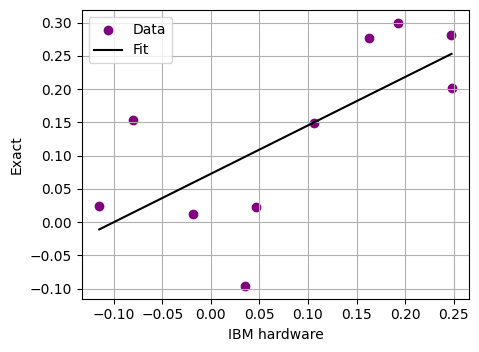

In [39]:
# Show the results in a plot
plot_mitigation(exact_values, values[1:], popt)

In [40]:
# Show the results in numbers
noisy_value = values[5]
exact_value = exact_values[5]

print(f"Noisy: {noisy_value}")
print(f"Exact: {exact_value}")
print(f"Mitig: {line(noisy_value, *popt)}")
print(f"\nMSE noisy: {(noisy_value-exact_value)**2}")
print(f"MSE mitig: {(line(noisy_value, *popt)-exact_value)**2}")

Noisy: 0.19251600196947316
Exact: 0.2815942405179772
Mitig: 0.21281029750902694

MSE noisy: 0.007934932582904192
MSE mitig: 0.004731230815858519


In [41]:
floq_ansatz = FloquetAnsatz(
    nqubits=45,
    nlayers=5,
    b=config["b"],
    theta=config["theta"],
)

In [42]:
print(floq_ansatz.circuit.summary())

Circuit depth = 102
Total number of gates = 3082
Number of qubits = 45
Most common gates:
rz: 1321
rx: 880
cx: 880
h: 1


In [43]:
len(floq_ansatz.circuit.get_parameters())

2201